# Question 2: Wage discrimination at promotion (Assoc → Full)

Does salary at promotion differ by sex after accounting for field, degree, cohort, and tenure?

## 1. Data loading

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from scipy.stats import ttest_ind

raw = pd.read_csv("salary.txt", sep=r"\s+")
df = raw.copy()
for c in ["sex", "deg", "field", "rank"]:
    df[c] = df[c].astype("category")
for c in ["case", "id", "yrdeg", "startyr", "year", "admin"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")
df["salary"] = pd.to_numeric(df["salary"], errors="coerce")
df.head()

,case,id,sex,deg,yrdeg,field,startyr,year,rank,admin,salary
0,1,1,F,Other,92,Other,95,95,Assist,0,6684.0
1,2,2,M,Other,91,Other,94,94,Assist,0,4743.0
2,3,2,M,Other,91,Other,94,95,Assist,0,4881.0
3,4,4,M,PhD,96,Other,95,95,Assist,0,4231.0
4,5,6,M,PhD,66,Other,91,91,Full,1,11182.0


## 2. Numerical summaries

In [3]:
df.describe(include=[np.number])

,case,id,yrdeg,startyr,year,admin,salary
count,19792.0,19792.0,19792.0,19792.0,19792.0,19792.0,19792.000000
mean,9896.5,883.503739,72.10676,76.072201,87.432346,0.105042,4721.823453
std,5713.6026,505.710683,8.504135,8.951341,5.556229,0.306616,1986.705277
min,1.0,1.0,48.0,48.0,76.0,0.0,1200.000000
25%,4948.75,461.0,67.0,69.0,83.0,0.0,3287.000000
50%,9896.5,873.0,72.0,76.0,88.0,0.0,4353.000000
75%,14844.25,1315.0,78.0,83.0,92.0,0.0,5794.000000
max,19792.0,1770.0,96.0,95.0,95.0,1.0,14464.000000


In [4]:
latest = df.sort_values(["id", "year"]).groupby("id").tail(1)
rank_by_sex = pd.crosstab(latest["sex"], latest["rank"]).reindex(columns=["Assoc", "Full"], fill_value=0)
rank_by_sex

rank,Assoc,Full
sex,,
F,138,126
M,299,719


In [5]:
salary_by_sex_rank = (
    latest[latest["rank"].isin(["Assoc", "Full"])]
    .groupby(["sex", "rank"], observed=True)["salary"]
    .agg(["count", "mean", "median", "std"])
)
salary_by_sex_rank

count         mean  median          std
sex rank                                          
F   Assoc    138  5018.922884  4743.0   858.125895
    Full     126  6839.724437  6590.0  1435.688449
M   Assoc    299  5480.492602  5095.0  1224.159629
    Full     719  7714.846330  7388.0  1943.371401

In [6]:
# First, ensure the data is sorted by ID and Year
df_sorted = df.sort_values(['id', 'year'])

# Create a 'previous_rank' column to compare
df_sorted['prev_rank'] = df_sorted.groupby('id')['rank'].shift(1)

# Define the promo_event: 
# It's True if they are now 'Full' but were 'Assoc' in the previous record
df_sorted['promo_event'] = (df_sorted['prev_rank'] == 'Assoc') & (df_sorted['rank'] == 'Full')

In [7]:
first_full = (
    df_sorted[df_sorted["promo_event"]].drop_duplicates("id")
    [["id", "sex", "yrdeg", "startyr", "field", "deg", "admin", "year", "salary"]]
    .rename(columns={"year": "promo_year", "salary": "salary_full"})
)
assoc_before = (
    df_sorted[df_sorted["rank"] == "Assoc"].merge(first_full[["id", "promo_year"]], on="id")
    .query("year < promo_year").sort_values(["id", "year"]).groupby("id").tail(1)
    [["id", "salary", "year"]].rename(columns={"salary": "salary_assoc", "year": "assoc_year"})
)
promo_pay = first_full.merge(assoc_before, on="id", how="left")
promo_pay["salary_delta"] = promo_pay["salary_full"] - promo_pay["salary_assoc"]

salary_at_promo = promo_pay.dropna(subset=["salary_full", "salary_delta"]).groupby("sex")["salary_full"].agg(["mean", "median", "std", "count"])
salary_raise = promo_pay.dropna(subset=["salary_delta"]).groupby("sex")["salary_delta"].agg(["mean", "median", "std", "count"])
salary_at_promo["metric"] = "salary at first Full"
salary_raise["metric"] = "salary raise (Full - last Assoc)"
salary_at_promo, salary_raise

/var/folders/tc/3mc7mhld2055qcl7sdcsm_mm0000gn/T/ipykernel_82097/3630835010.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salary_at_promo = promo_pay.dropna(subset=["salary_full", "salary_delta"]).groupby("sex")["salary_full"].agg(["mean", "median", "std", "count"])
/var/folders/tc/3mc7mhld2055qcl7sdcsm_mm0000gn/T/ipykernel_82097/3630835010.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salary_raise = promo_pay.dropna(subset=["salary_delta"]).groupby("sex")["salary_delta"].agg(["mean", "median", "std", "count"])


(            mean  median          std  count                metric
 sex                                                               
 F    4669.588710  4667.0  1229.297277    100  salary at first Full
 M    4511.310105  4319.0  1521.352250    446  salary at first Full,
            mean    median         std  count                            metric
 sex                                                                           
 F    516.686970  446.0000  365.071823    100  salary raise (Full - last Assoc)
 M    463.290684  362.8435  369.822779    446  salary raise (Full - last Assoc))

In [8]:
df_sorted = df.sort_values(["id", "year"])
rank_shift = df_sorted.groupby("id")["rank"].shift(1)
df_sorted["promo_event"] = (
    (rank_shift == "Assoc") & (df_sorted["rank"] == "Full") & (rank_shift != df_sorted["rank"])
)
promo_year = df_sorted.loc[df_sorted["promo_event"], ["id", "year"]].drop_duplicates("id").rename(columns={"year": "promo_year"})
people = df_sorted[["id", "sex", "yrdeg", "startyr"]].drop_duplicates("id").merge(promo_year, on="id", how="left")
people["yrs_to_promo"] = people["promo_year"] - people["startyr"]
people["promoted"] = people["promo_year"].notna()

promo_table = people.groupby("sex", observed=True)["promoted"].agg(["sum", "count"])
promo_table.columns = ["promoted", "n"]
promo_table["prop"] = promo_table["promoted"] / promo_table["n"]
promo_table

,promoted,n,prop
sex,,,
F,100,409,0.244499
M,446,1188,0.375421


## 3. Visualizations

/var/folders/tc/3mc7mhld2055qcl7sdcsm_mm0000gn/T/ipykernel_82097/640050213.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = pp.groupby("sex")["salary_full"].agg(["mean", "count", "std"])


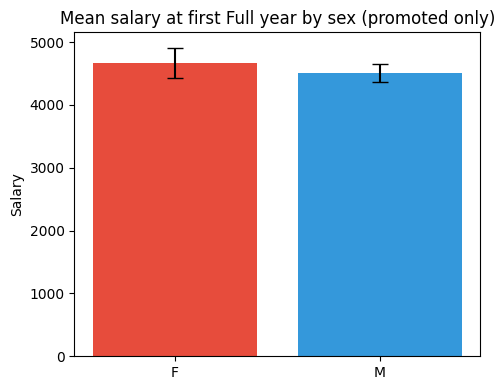

In [9]:
pp = promo_pay.dropna(subset=["salary_full", "salary_delta"])
means = pp.groupby("sex")["salary_full"].agg(["mean", "count", "std"])
means["se"] = means["std"] / np.sqrt(means["count"])
means["ci"] = 1.96 * means["se"]
fig, ax = plt.subplots(figsize=(5, 4))
x = [0, 1]
ax.bar(x, means["mean"], yerr=means["ci"], capsize=6, color=["#e74c3c", "#3498db"], tick_label=["F", "M"])
ax.set_title("Mean salary at first Full year by sex (promoted only)")
ax.set_ylabel("Salary")
plt.tight_layout()
plt.show()

/var/folders/tc/3mc7mhld2055qcl7sdcsm_mm0000gn/T/ipykernel_82097/2927407596.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  m2 = pp2.groupby("sex")["salary_delta"].agg(["mean", "count", "std"])


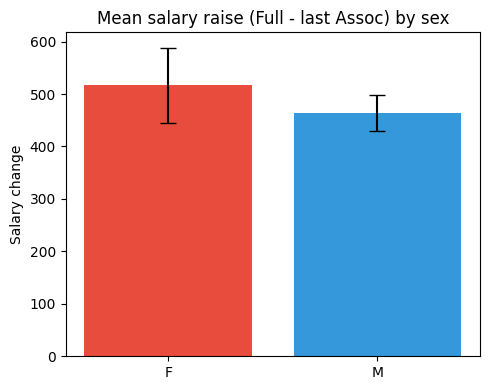

In [10]:
pp2 = promo_pay.dropna(subset=["salary_delta"])
m2 = pp2.groupby("sex")["salary_delta"].agg(["mean", "count", "std"])
m2["se"] = m2["std"] / np.sqrt(m2["count"])
m2["ci"] = 1.96 * m2["se"]
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([0, 1], m2["mean"], yerr=m2["ci"], capsize=6, color=["#e74c3c", "#3498db"], tick_label=["F", "M"])
ax.set_title("Mean salary raise (Full - last Assoc) by sex")
ax.set_ylabel("Salary change")
plt.tight_layout()
plt.show()

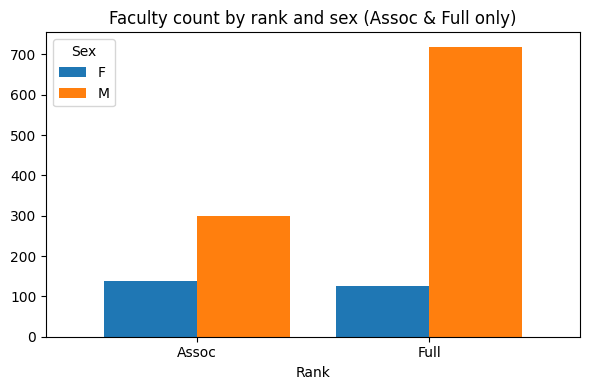

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
rank_by_sex.T.plot(kind="bar", ax=ax, width=0.8)
ax.set_title("Faculty count by rank and sex (Assoc & Full only)")
ax.set_xlabel("Rank")
ax.legend(title="Sex")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

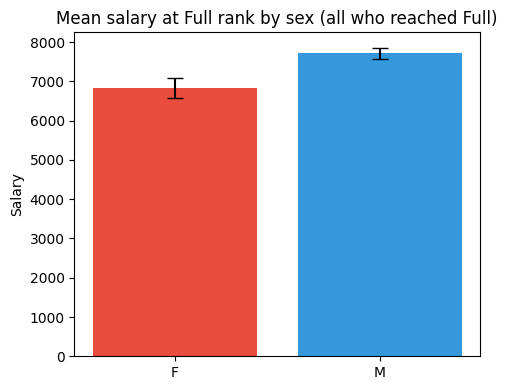

In [12]:
full_only = latest[latest["rank"] == "Full"].groupby("sex", observed=True)["salary"].agg(["mean", "count", "std"])
full_only["se"] = full_only["std"] / np.sqrt(full_only["count"])
full_only["ci"] = 1.96 * full_only["se"]
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([0, 1], full_only["mean"], yerr=full_only["ci"], capsize=6, color=["#e74c3c", "#3498db"], tick_label=["F", "M"])
ax.set_title("Mean salary at Full rank by sex (all who reached Full)")
ax.set_ylabel("Salary")
plt.tight_layout()
plt.show()

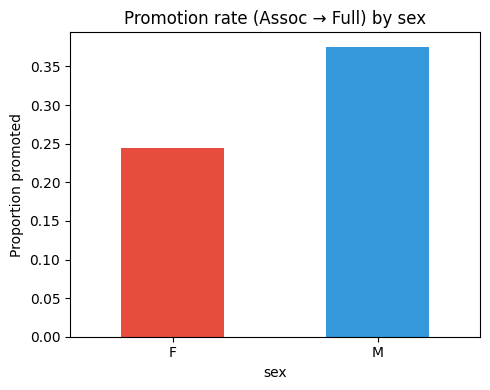

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
promo_table["prop"].plot(kind="bar", ax=ax, color=["#e74c3c", "#3498db"])
ax.set_title("Promotion rate (Assoc → Full) by sex")
ax.set_ylabel("Proportion promoted")
ax.set_xticklabels(["F", "M"], rotation=0)
plt.tight_layout()
plt.show()

## 4. Inference: linear regression for wage gap at promotion

In [14]:
first_full = (
    df_sorted[df_sorted["promo_event"]].drop_duplicates("id")[["id", "sex", "yrdeg", "startyr", "field", "deg", "admin", "year", "salary"]]
    .rename(columns={"year": "promo_year", "salary": "salary_full"})
)
assoc_before = df_sorted[df_sorted["rank"] == "Assoc"].merge(first_full[["id", "promo_year"]], on="id")
assoc_before = assoc_before[assoc_before["year"] < assoc_before["promo_year"]].sort_values(["id", "year"]).groupby("id").tail(1)[["id", "salary", "year"]].rename(columns={"salary": "salary_assoc", "year": "assoc_year"})
promo_pay = first_full.merge(assoc_before, on="id", how="left")
promo_pay["salary_delta"] = promo_pay["salary_full"] - promo_pay["salary_assoc"]
promo_pay["years_since_degree"] = promo_pay["promo_year"] - promo_pay["yrdeg"]
promo_pay["years_at_inst"] = promo_pay["promo_year"] - promo_pay["startyr"]
promo_pay.head()

,id,sex,yrdeg,startyr,field,deg,admin,promo_year,salary_full,salary_assoc,assoc_year,salary_delta,years_since_degree,years_at_inst
0,10,M,68,80,Arts,PhD,1,93,7180.0,6781.0,92,399.0,25,13
1,13,M,68,69,Prof,PhD,0,82,3322.0,3137.0,81,185.0,14,13
2,14,M,79,92,Other,PhD,0,94,9025.0,8770.0,93,255.0,15,2
3,16,M,73,79,Other,PhD,0,89,5290.0,4538.0,88,752.0,16,10
4,17,M,72,72,Other,PhD,0,83,2994.0,2838.0,82,156.0,11,11


In [15]:
import statsmodels.formula.api as smf

ols_df = promo_pay.dropna(subset=["salary_full", "salary_delta"])

ols_full = smf.ols(
    "salary_full ~ C(sex) + yrdeg + C(field) + C(deg) + admin + years_since_degree + years_at_inst",
    data=ols_df
).fit(cov_type="HC3")

ols_delta = smf.ols(
    "salary_delta ~ C(sex) + yrdeg + C(field) + C(deg) + admin + years_since_degree + years_at_inst",
    data=ols_df
).fit(cov_type="HC3")

print("Salary at first Full year:")
print(ols_full.summary())
print("\nSalary raise (Full - last Assoc):")
print(ols_delta.summary())

Salary at first Full year:
                            OLS Regression Results                            
Dep. Variable:            salary_full   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     202.1
Date:                Wed, 11 Mar 2026   Prob (F-statistic):          5.97e-166
Time:                        19:52:16   Log-Likelihood:                -4385.4
No. Observations:                 546   AIC:                             8791.
Df Residuals:                     536   BIC:                             8834.
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept

/var/folders/tc/3mc7mhld2055qcl7sdcsm_mm0000gn/T/ipykernel_82097/4282338733.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, widths=0.5, labels=["F", "M"])
/var/folders/tc/3mc7mhld2055qcl7sdcsm_mm0000gn/T/ipykernel_82097/4282338733.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, widths=0.5, labels=["F", "M"])


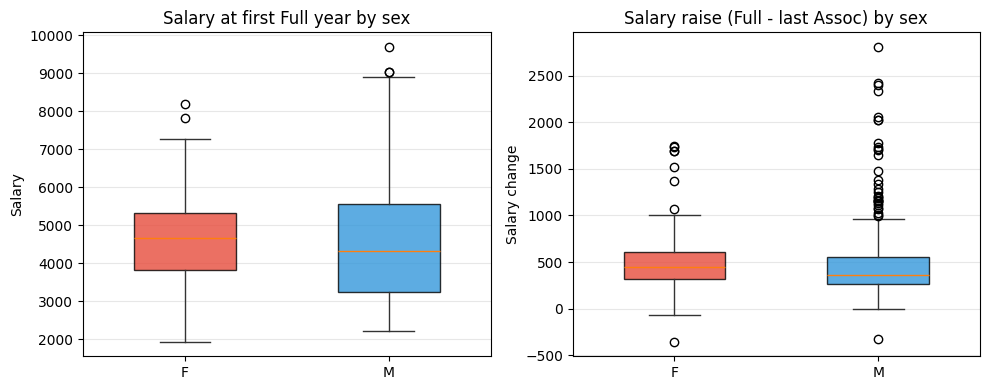

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ["#e74c3c", "#3498db"]

for ax, col, title, ylabel in [
    (axes[0], "salary_full", "Salary at first Full year by sex", "Salary"),
    (axes[1], "salary_delta", "Salary raise (Full - last Assoc) by sex", "Salary change"),
]:
    data = [ols_df[ols_df["sex"] == "F"][col].dropna(), ols_df[ols_df["sex"] == "M"][col].dropna()]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5, labels=["F", "M"])
    for i, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(colors[i])
        patch.set_alpha(0.8)
    for el in ["whiskers", "fliers", "caps"]:
        for x in bp[el]:
            x.set_color("#333")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

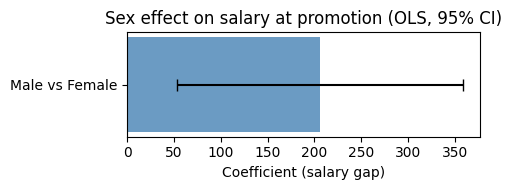

In [17]:
sex_coef = ols_full.params["C(sex)[T.M]"]
sex_ci = ols_full.conf_int().loc["C(sex)[T.M]"]
fig, ax = plt.subplots(figsize=(5, 2))
ax.barh(["Male vs Female"], [sex_coef], color="steelblue", alpha=0.8)
err = max(sex_coef - sex_ci[0], sex_ci[1] - sex_coef)
ax.errorbar([sex_coef], [0], xerr=err, fmt="none", color="black", capsize=4)
ax.axvline(0, color="gray", linestyle="--")
ax.set_xlabel("Coefficient (salary gap)")
ax.set_title("Sex effect on salary at promotion (OLS, 95% CI)")
plt.tight_layout()
plt.show()

# Jianna's Visualizations

In [18]:
# Calculate Mean and Median Salaries
stats = df.groupby(['rank', 'sex'])['salary'].agg(['mean', 'median']).reset_index()

# Calculate Promotion Percentage Increase
pivot_mean = stats.pivot(index='sex', columns='rank', values='mean')
pivot_mean['pct_increase'] = ((pivot_mean['Full'] - pivot_mean['Assoc']) / pivot_mean['Assoc']) * 100

print("--- Descriptive Statistics ---")
print(stats)
print("\n--- Percentage Increase from Assoc to Full ---")
print(pivot_mean[['pct_increase']])

--- Descriptive Statistics ---
     rank sex         mean     median
0  Assist   F  3390.336892  3411.7785
1  Assist   M  3387.458765  3314.0000
2   Assoc   F  4013.478557  4053.0000
3   Assoc   M  3965.813033  3860.3335
4    Full   F  5596.890050  5408.0000
5    Full   M  5865.128429  5586.5000

--- Percentage Increase from Assoc to Full ---
rank  pct_increase
sex               
F        39.452347
M        47.892207


/var/folders/tc/3mc7mhld2055qcl7sdcsm_mm0000gn/T/ipykernel_82097/413541653.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby(['rank', 'sex'])['salary'].agg(['mean', 'median']).reset_index()


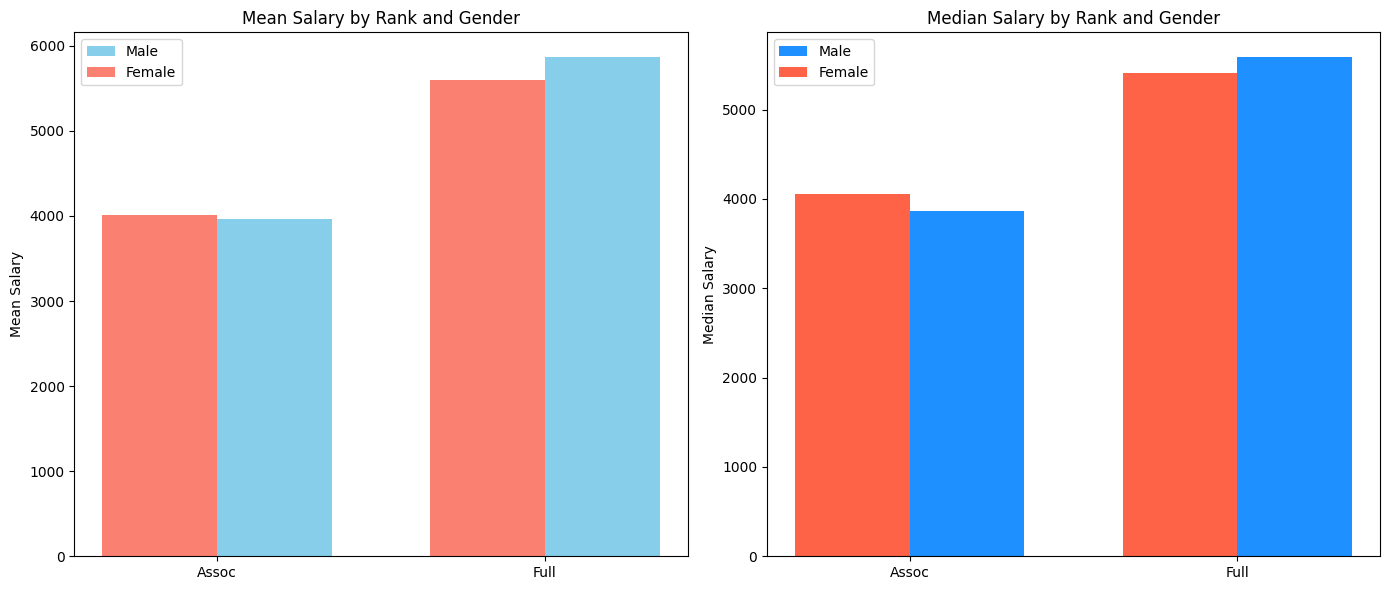

In [19]:
# --- VISUALIZATIONS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Mean Salaries (Bar Chart)
labels = ['Assoc', 'Full']
x = np.arange(len(labels))
width = 0.35

male_means = [stats[(stats['rank']=='Assoc') & (stats['sex']=='M')]['mean'].values[0],
              stats[(stats['rank']=='Full') & (stats['sex']=='M')]['mean'].values[0]]
female_means = [stats[(stats['rank']=='Assoc') & (stats['sex']=='F')]['mean'].values[0],
                stats[(stats['rank']=='Full') & (stats['sex']=='F')]['mean'].values[0]]

ax1.bar(x + width/2, male_means, width, label='Male', color='skyblue')
ax1.bar(x - width/2, female_means, width, label='Female', color='salmon')

ax1.set_ylabel('Mean Salary')
ax1.set_title('Mean Salary by Rank and Gender')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend()
# Plot 2: Median Salaries (Bar Chart)
male_medians = [stats[(stats['rank']=='Assoc') & (stats['sex']=='M')]['median'].values[0],
                stats[(stats['rank']=='Full') & (stats['sex']=='M')]['median'].values[0]]
female_medians = [stats[(stats['rank']=='Assoc') & (stats['sex']=='F')]['median'].values[0],
                  stats[(stats['rank']=='Full') & (stats['sex']=='F')]['median'].values[0]]

ax2.bar(x + width/2, male_medians, width, label='Male', color='dodgerblue')
ax2.bar(x - width/2, female_medians, width, label='Female', color='tomato')

ax2.set_ylabel('Median Salary')
ax2.set_title('Median Salary by Rank and Gender')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.legend()

plt.tight_layout()
plt.show()

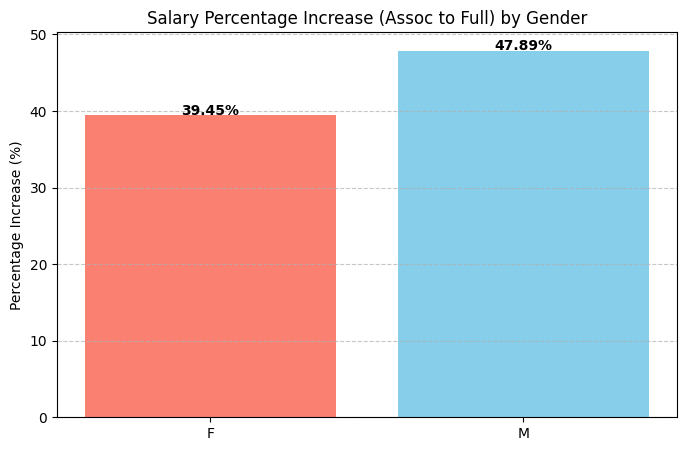

In [20]:
plt.figure(figsize=(8, 5))
plt.bar(pivot_mean.index, pivot_mean['pct_increase'], color=['salmon', 'skyblue'])
plt.title('Salary Percentage Increase (Assoc to Full) by Gender')
plt.ylabel('Percentage Increase (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, val in enumerate(pivot_mean['pct_increase']):
    plt.text(i, val + 0.1, f'{val:.2f}%', ha='center', fontweight='bold')

plt.show()

At the Associate (Assoc) level, women actually have a slightly higher mean salary than men (approx. 4,013 vs. 3,965). However, the "Percentage Increase" chart shows a stark difference in career progression. Men receive a 47.89% increase when moving from Associate to Full Professor, while women only see a 39.45% increase. By the time they reach Full Professor, men have surpassed women in both mean and median salary.

In [21]:
model_q2 = smf.ols('salary ~ sex * rank + field + yrdeg + admin', data=df).fit()

print(model_q2.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.389
Method:                 Least Squares   F-statistic:                     1403.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:52:18   Log-Likelihood:            -1.7347e+05
No. Observations:               19788   AIC:                         3.470e+05
Df Residuals:                   19778   BIC:                         3.470e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -2593

The coefficient for sex is 337.27. This means that when holding all other factors (rank, degree, field, years, admin status) constant, being male is associated with a 337.27 higher salary than being female. Since the p-value is 0.000, this is statistically significant. Every additional year adds 
221.46 to the salary, and having an administrative role (admin) adds a substantial 811.70. Moving to a Full Professor rank adds 1,863.53 compared to the baseline (likely Assistant Professor), which is the single largest predictor in the model.

In [22]:
anova_formula = 'salary ~ C(sex) * C(rank)'
anova_model = smf.ols(anova_formula, data=df).fit()
anova_results = anova_lm(anova_model, typ=2)

print("\n--- Two-Way ANOVA Results ---")
print(anova_results)


--- Two-Way ANOVA Results ---
                      sum_sq       df            F    PR(>F)
C(sex)          1.124226e+07      1.0     3.986383  0.045883
C(rank)         2.085969e+10      2.0  3698.310818  0.000000
C(sex):C(rank)  5.554374e+07      2.0     9.847606  0.000053
Residual        5.578849e+10  19782.0          NaN       NaN


 The p-value is extremely low ($0.000053$). This confirms that the effect of rank on salary depends on gender. This statistically supports what the Percentage Increase graph showed: the financial gain for reaching the highest rank is significantly different for men than it is for women.

### Is the amount of promotion wage different between the two groups?

In [23]:
# 1. Isolate all Associate and Full records
assoc_records = df[df['rank'] == 'Assoc'].sort_values(['id', 'year'])
full_records = df[df['rank'] == 'Full'].sort_values(['id', 'year'])

# 2. Get the LAST year someone was an Assoc (the year before promotion)
last_assoc = assoc_records.groupby('id').last().reset_index()

# 3. Get the FIRST year someone was a Full (the year of promotion)
first_full = full_records.groupby('id').first().reset_index()

promo_df = pd.merge(
    last_assoc[['id', 'salary', 'year']], 
    first_full, 
    on='id', 
    suffixes=('_assoc', '_full')
)

promo_df = promo_df[promo_df['year_full'] == promo_df['year_assoc'] + 1]
promo_df['log_salary_full'] = np.log(promo_df['salary_full'])
promo_df['log_salary_assoc'] = np.log(promo_df['salary_assoc'])
promo_df['years_at_inst'] = promo_df['year_full'] - promo_df['startyr']
promo_df['years_since_degree'] = promo_df['year_full'] - promo_df['yrdeg']
promo_df['pct_jump'] = promo_df['log_salary_full'] - promo_df['log_salary_assoc']
formula_pct = 'pct_jump ~ C(sex) + yrdeg + C(field) + C(deg) + admin + years_since_degree + years_at_inst'
model_pct = smf.ols(formula_pct, data=promo_df).fit()
print(model_pct.summary())

                            OLS Regression Results                            
Dep. Variable:               pct_jump   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     4.078
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           4.47e-05
Time:                        19:52:20   Log-Likelihood:                 680.09
No. Observations:                 534   AIC:                            -1340.
Df Residuals:                     524   BIC:                            -1297.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.2571      0

Does Wage Discrimination Exist in Promotions?
No
Coefficient for C(sex)[T.M]: -0.0058
P-value: 0.544
Men actually received about 0.58% less of a percentage jump than women, but because the p-value is so high (0.544), this difference is statistically insignificant. You cannot claim there is a gender difference in the promotion raise magnitude.

What Does Affect the Promotion Jump?
Two variables actually matter here, and they aren't gender:
C(field)[T.Other] (P = 0.007): Professors in the "Other" fields received about a 3% smaller raise (-0.0298) compared to the reference group (likely Arts).
years_since_degree (P = 0.007): For every additional year that has passed since a professor got their degree, their promotion jump decreases by about 0.28%. This suggests that "late bloomers" or those who take longer to reach Full Professor see slightly smaller percentage increases than those who move up quickly.

### Are men are being promoted more than women?

In [26]:
df_sorted = df.sort_values(["id", "year"])
rank_shift = df_sorted.groupby("id")["rank"].shift(1)
df_sorted["promo_event"] = (
    (rank_shift == "Assoc") & (df_sorted["rank"] == "Full") & (rank_shift != df_sorted["rank"])
)
promo_year = df_sorted.loc[df_sorted["promo_event"], ["id", "year"]].drop_duplicates("id").rename(columns={"year": "promo_year"})
people = df_sorted[["id", "sex", "yrdeg", "startyr"]].drop_duplicates("id").merge(promo_year, on="id", how="left")
people["yrs_to_promo"] = people["promo_year"] - people["startyr"]
people["promoted"] = people["promo_year"].notna()

promo_table = people.groupby("sex", observed=True)["promoted"].agg(["sum", "count"])
promo_table.columns = ["promoted", "n"]
promo_table["prop"] = promo_table["promoted"] / promo_table["n"]
promo_table

,promoted,n,prop
sex,,,
F,100,409,0.244499
M,446,1188,0.375421


In [24]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency

senior_faculty = df[df['rank'].isin(['Assoc', 'Full'])].copy()
senior_faculty['is_full'] = (senior_faculty['rank'] == 'Full').astype(int)

# 1. Logistic Regression: Probability of being 'Full' controlled for years since degree
logit_model = smf.logit('is_full ~ C(sex) + yrdeg + C(field)', data=senior_faculty).fit()
print("--- Logistic Regression: Likelihood of being a Full Professor ---")
print(logit_model.summary())

# 2. Simple Chi-Squared Test
contingency_table = pd.crosstab(senior_faculty['sex'], senior_faculty['rank'])
chi2, p, dof, ex = chi2_contingency(contingency_table)
print(f"\nChi-Squared P-value (Raw Proportions): {p:.5f}")

Optimization terminated successfully.
         Current function value: 0.562602
         Iterations 6
--- Logistic Regression: Likelihood of being a Full Professor ---
                           Logit Regression Results                           
Dep. Variable:                is_full   No. Observations:                15740
Model:                          Logit   Df Residuals:                    15735
Method:                           MLE   Df Model:                            4
Date:                Wed, 11 Mar 2026   Pseudo R-squ.:                  0.1709
Time:                        19:52:22   Log-Likelihood:                -8855.4
converged:                       True   LL-Null:                       -10681.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             9.8126

In [27]:
print(logit_model.pvalues)

Intercept            0.000000e+00
C(sex)[T.M]          4.320318e-11
C(field)[T.Other]    8.752288e-57
C(field)[T.Prof]     7.446186e-81
yrdeg                0.000000e+00
dtype: float64


The p-value is less than 0.05 so we reject the null hypothesis that men and women are promoted at equal rates. Men are promoted at higher rates for the same seniority.

/var/folders/tc/3mc7mhld2055qcl7sdcsm_mm0000gn/T/ipykernel_82097/1269933783.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interaction_data = df.groupby(['rank', 'sex'])['salary'].mean().reset_index()


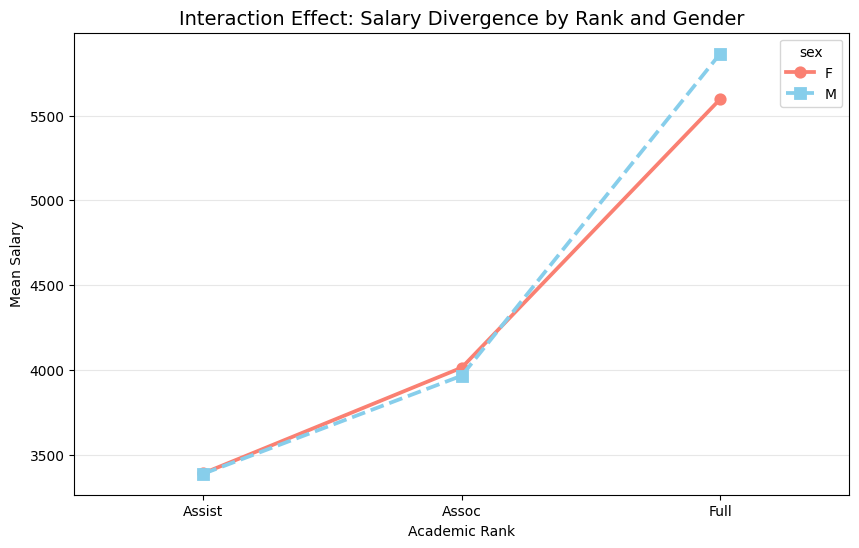

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean salaries by Rank and Sex
interaction_data = df.groupby(['rank', 'sex'])['salary'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.pointplot(data=interaction_data, x='rank', y='salary', hue='sex', 
              markers=["o", "s"], linestyles=["-", "--"], palette=['salmon', 'skyblue'])

plt.title('Interaction Effect: Salary Divergence by Rank and Gender', fontsize=14)
plt.ylabel('Mean Salary')
plt.xlabel('Academic Rank')
plt.grid(axis='y', alpha=0.3)
plt.show()